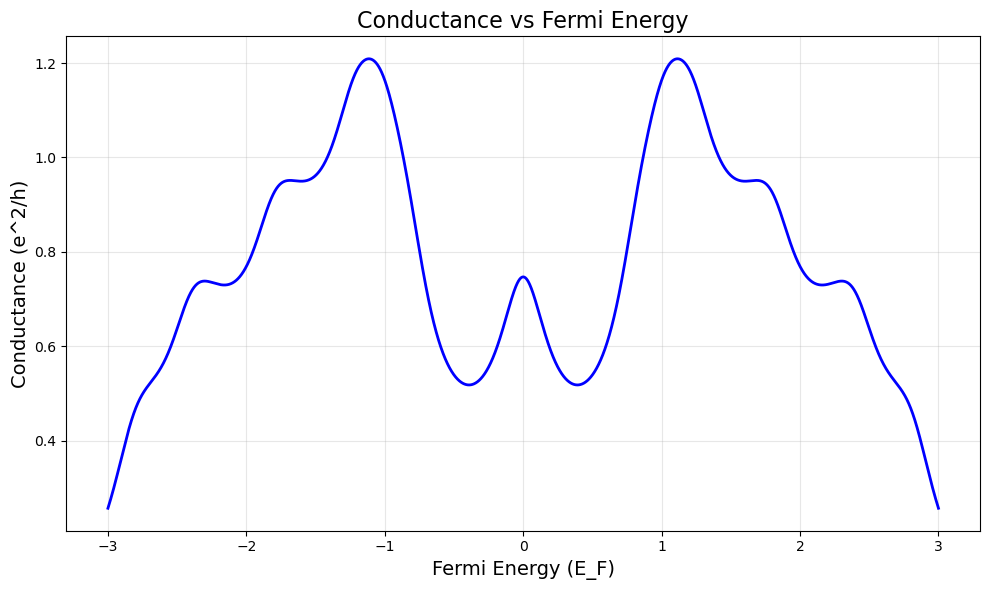

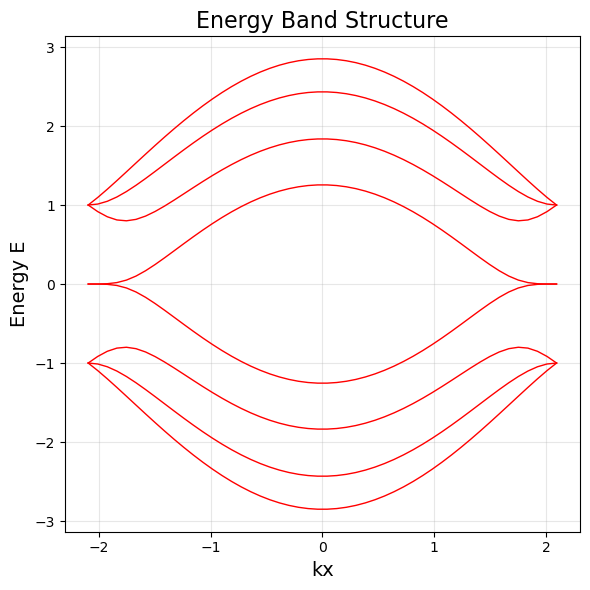

电导计算完成，费米能级范围: -3.00 到 3.00
电导范围: 0.2565 到 1.2090 e^2/h


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import inv

# 参数设置
a = 1
t = 1
V = 0
k = 4
eta = 1e-4  # 小虚部，用于数值稳定性

def H_func_shi(a, kx, t, k, V):   
    H_matrix = np.zeros((2*k, 2*k), dtype=complex)
    for i in range(0, 2*k, 2):
        if i == 0:
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = t*(1+np.exp(-1j*1.5*a*kx))
            H_matrix[i+1, i] = t*(1+np.exp(+1j*1.5*a*kx))
            H_matrix[i+1, i+1] = V 
            H_matrix[i+1, i+2] = t
        elif i == 2*k-2:
            H_matrix[i, i-1] = t
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = t*(1+np.exp(-1j*1.5*a*kx))
            H_matrix[i+1, i] = t*(1+np.exp(+1j*1.5*a*kx))
            H_matrix[i+1, i+1] = V 
        else:  
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = t*(1+np.exp(-1j*1.5*a*kx))
            H_matrix[i+1, i] = t*(1+np.exp(+1j*1.5*a*kx))
            H_matrix[i+1, i+1] = V
            H_matrix[i, i-1] = t
            H_matrix[i+1, i+2] = t
    return H_matrix

def calculate_conductance(kx, E_F, gamma_L, gamma_R):
    """计算电导"""
    H = H_func_shi(a, kx, t, k, V)
    n = H.shape[0]
    
    # 推迟格林函数 G^r(E) = [E - H - Σ^r]^{-1}
    # 这里简化处理，假设自能只来自左右接触
    Sigma_L = -1j * gamma_L * np.eye(n)  # 左接触自能
    Sigma_R = -1j * gamma_R * np.eye(n)  # 右接触自能
    
    # 总自能
    Sigma = Sigma_L + Sigma_R
    
    # 推迟格林函数
    G_r = inv((E_F + 1j*eta) * np.eye(n) - H - Sigma)
    
    # 推迟格林函数的厄米共轭
    G_a = G_r.conj().T
    
    # 线宽函数
    Gamma_L = 1j * (Sigma_L - Sigma_L.conj().T)
    Gamma_R = 1j * (Sigma_R - Sigma_R.conj().T)
    
    # 使用Landauer公式计算电导: G = (e^2/h) * Tr[Γ_L G^r Γ_R G^a]
    transmission = np.trace(Gamma_L @ G_r @ Gamma_R @ G_a).real
    conductance = transmission  # 单位: e^2/h
    
    return conductance

# 费米能级范围
E_F_range = np.linspace(-3, 3, 10000)
kx_set = np.linspace(-np.pi/(1.5*a), np.pi/(1.5*a), 50)

# 接触耦合强度
gamma_L = 0.1  # 左接触耦合
gamma_R = 0.1  # 右接触耦合

# 计算电导
conductance_results = []

for E_F in E_F_range:
    total_conductance = 0
    for kx in kx_set:
        total_conductance += calculate_conductance(kx, E_F, gamma_L, gamma_R)
    
    # 对kx求平均
    avg_conductance = total_conductance / len(kx_set)
    conductance_results.append(avg_conductance)

# 绘制电导随费米能级的变化
plt.figure(figsize=(10, 6))
plt.plot(E_F_range, conductance_results, 'b-', linewidth=2)
plt.xlabel('Fermi Energy (E_F)', fontsize=14)
plt.ylabel('Conductance (e^2/h)', fontsize=14)
plt.title('Conductance vs Fermi Energy', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 绘制能带结构作为参考
plt.figure(figsize=(6, 6))
jueguo = [[] for _ in range(k*2)]

for kx in kx_set:
    H_matrix = H_func_shi(a, kx, t, k, V)
    eigenvalues = np.linalg.eigvals(H_matrix)
    eigenvalues_sorted = sorted(eigenvalues, key=lambda x: x.real)
    
    for j in range(2*k):
        jueguo[j].append(eigenvalues_sorted[j].real)

for band_idx in range(2*k):
    plt.plot(kx_set, jueguo[band_idx], 'r-', linewidth=1)

plt.xlabel('kx', fontsize=14)
plt.ylabel('Energy E', fontsize=14)
plt.title('Energy Band Structure', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"电导计算完成，费米能级范围: {E_F_range[0]:.2f} 到 {E_F_range[-1]:.2f}")
print(f"电导范围: {min(conductance_results):.4f} 到 {max(conductance_results):.4f} e^2/h")